In [1]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

---
# Ejercicio 1 — Generador congruencial lineal

Dado $x_0 = 3$ y la regla:
$$x_n = (5x_{n-1} + 7) \mod 200$$
generamos $x_1 \ldots x_{10}$, los normalizamos dividiendo por 200 y comparamos con los valores **teóricos** de una $\text{Uniforme}(0,1)$:

| Estadístico | Fórmula | Valor teórico |
|---|---|---|
| Media | $1/2$ | $0.5000$ |
| Varianza | $1/12$ | $0.0833$ |
| Desvío estándar | $1/\sqrt{12}$ | $0.2887$ |

Primeros 10 enteros: [22, 117, 192, 167, 42, 17, 92, 67, 142, 117, 192, 167, 42, 17, 92]
Primeros 10 normalizados:    [0.11  0.585 0.96  0.835 0.21  0.085 0.46  0.335 0.71  0.585 0.96  0.835
 0.21  0.085 0.46 ]


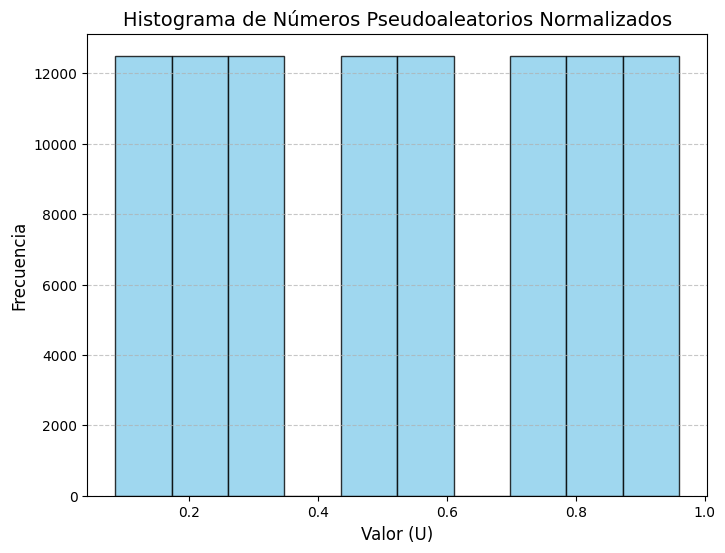

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ── GENERAR LA SECUENCIA ─────────────────────────────────────────────────────
x0 = 3
n  = 100000

secuencia = [x0]
for _ in range(n):
    secuencia.append((5 * secuencia[-1] + 7) % 200)

x_generados = secuencia[1:]          # x_1 ... x_100 enteros
u      = np.array(x_generados) / 200 # normalizados en [0, 1)

print("Primeros 10 enteros:", x_generados[:15])
print("Primeros 10 normalizados:   ", np.round(u[:15], 4))

# ── HISTOGRAMA ───────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

plt.hist(u, bins=10, color='skyblue', edgecolor='black', alpha=0.8)

plt.title('Histograma de Números Pseudoaleatorios Normalizados', fontsize=14)
plt.xlabel('Valor (U)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()

In [11]:
# ── COMPARACIÓN EMPÍRICO vs TEÓRICO ─────────────────────────────────────────
media_emp  = np.mean(u)
var_emp    = np.var(u, ddof=1)
desvio_emp = np.std(u, ddof=1)

media_teo  = 0.5
var_teo    = 1 / 12
desvio_teo = 1 / np.sqrt(12)

print(f"{'Estadístico':<22} {'Empírico (n=10)':>16} {'Teórico Unif(0,1)':>18} {'|Diferencia|':>14}")
print("-" * 72)
print(f"{'Media':<22} {media_emp:>16.4f} {media_teo:>18.4f} {abs(media_emp - media_teo):>14.4f}")
print(f"{'Varianza':<22} {var_emp:>16.4f} {var_teo:>18.4f} {abs(var_emp - var_teo):>14.4f}")
print(f"{'Desvío estándar':<22} {desvio_emp:>16.4f} {desvio_teo:>18.4f} {abs(desvio_emp - desvio_teo):>14.4f}")
print()
print("Nota: con n=10 la muestra es muy chica — las diferencias son esperables.")
print(f"El generador tiene período 200, con n>200 empieza a repetirse.")

Estadístico             Empírico (n=10)  Teórico Unif(0,1)   |Diferencia|
------------------------------------------------------------------------
Media                            0.5225             0.5000         0.0225
Varianza                         0.0820             0.0833         0.0013
Desvío estándar                  0.2864             0.2887         0.0023

Nota: con n=10 la muestra es muy chica — las diferencias son esperables.
El generador tiene período 200, con n>200 empieza a repetirse.


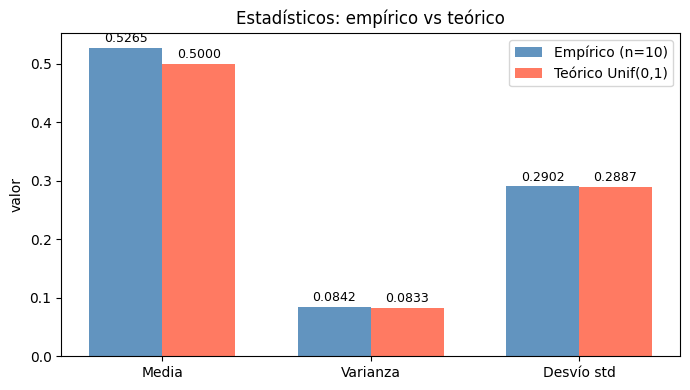

In [19]:
# ── GRÁFICO 2: barras empírico vs teórico para cada estadístico ──────────────
fig, ax = plt.subplots(figsize=(7, 4))

labels   = ['Media', 'Varianza', 'Desvío std']
emp_vals = [media_emp, var_emp, desvio_emp]
teo_vals = [media_teo, var_teo, desvio_teo]
x_pos    = np.arange(len(labels))
w        = 0.35

b1 = ax.bar(x_pos - w/2, emp_vals, w, label='Empírico (n=10)',    color='steelblue', alpha=0.85)
b2 = ax.bar(x_pos + w/2, teo_vals, w, label='Teórico Unif(0,1)', color='tomato',    alpha=0.85)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel('valor')
ax.set_title('Estadísticos: empírico vs teórico')
ax.legend()
plt.tight_layout()
plt.show()

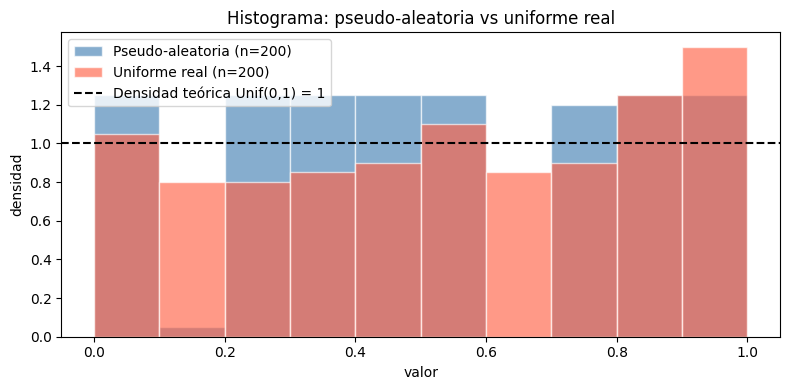

In [23]:
# ── GRÁFICO 4: histograma pseudo-aleatoria vs uniforme real ──────────────────
n_max     = 200
seq_larga = [x0]
for _ in range(n_max):
    seq_larga.append((5 * seq_larga[-1] + 7) % 200)
u_larga     = np.array(seq_larga[1:]) / 200
medias_acum = np.cumsum(u_larga) / np.arange(1, n_max + 1)
ns          = np.arange(1, n_max + 1)


u_real = np.random.default_rng(0).uniform(0, 1, 200)
bins   = np.linspace(0, 1, 11)  # 10 bins de ancho 0.1

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(u_larga, bins=bins, alpha=0.65, density=True,
        label='Pseudo-aleatoria (n=200)', color='steelblue', edgecolor='white')
ax.hist(u_real,  bins=bins, alpha=0.65, density=True,
        label='Uniforme real (n=200)',    color='tomato',    edgecolor='white')
ax.axhline(1, color='black', linestyle='--', linewidth=1.5,
           label='Densidad teórica Unif(0,1) = 1')
ax.set_xlabel('valor')
ax.set_ylabel('densidad')
ax.set_title('Histograma: pseudo-aleatoria vs uniforme real')
ax.legend()
plt.tight_layout()
plt.show()

---
# Ejercicio 4 — Generar valores de una PMF dada

Distribución discreta:
- $P(X=1) = p_1 = 1/3 \approx 0.3333$
- $P(X=2) = p_2 = 2/3 \approx 0.6667$

**Método de inversión:** generamos $U \sim \text{Uniforme}(0,1)$ y asignamos $X=1$ si $U < 1/3$, sino $X=2$.

Comparamos la **proporción empírica** de unos contra el **valor teórico** $p_1 = 1/3$ para $n = 100, 1000, 10000$.

In [31]:
# ── FUNCIÓN GENERADORA ────────────────────────────────────────────────────────
def generar_pmf(n, seed=42):
    """Genera n valores con P(X=1)=1/3 y P(X=2)=2/3 por método de inversión."""
    rng = np.random.default_rng(seed)
    U   = rng.uniform(0, 1, n)
    return np.where(U < 1/3, 1, 2)

p1_teo = 1/3
p2_teo = 2/3

# ── TABLA COMPARATIVA ────────────────────────────────────────────────────────
print(f"{'n':>8}  {'Prop X=1 emp':>14}  {'Prop X=2 emp':>14}  "
      f"{'Teo p1':>10}  {'Teo p2':>10}  {'Error p1':>10}")
print("-" * 75)

for n in [10, 10000]:
    X     = generar_pmf(n)
    p1emp = np.mean(X == 1)
    p2emp = np.mean(X == 2)
    err   = abs(p1emp - p1_teo)
    print(f"{n:>8,}  {p1emp:>14.4f}  {p2emp:>14.4f}  "
          f"{p1_teo:>10.4f}  {p2_teo:>10.4f}  {err:>10.4f}")

       n    Prop X=1 emp    Prop X=2 emp      Teo p1      Teo p2    Error p1
---------------------------------------------------------------------------
      10          0.2000          0.8000      0.3333      0.6667      0.1333
  10,000          0.3375          0.6625      0.3333      0.6667      0.0042


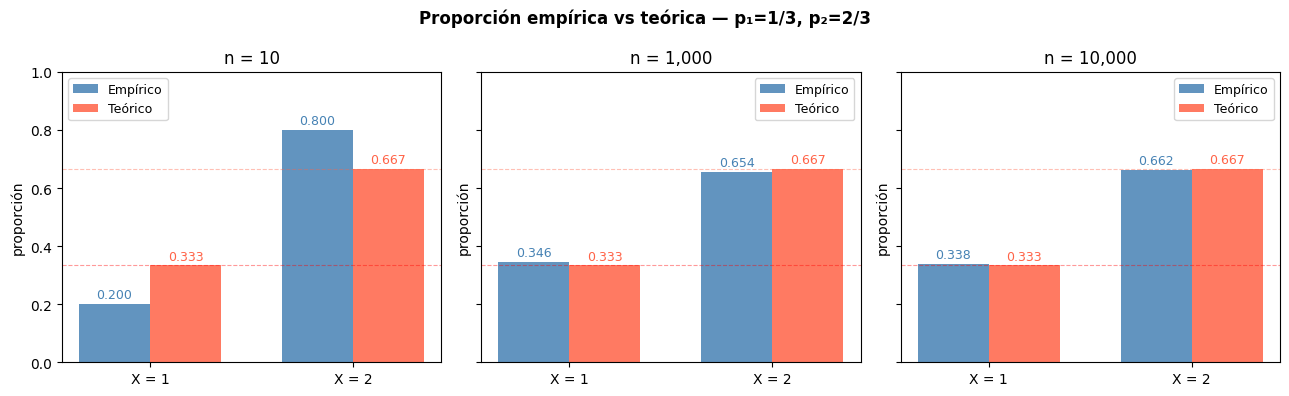

In [22]:
# ── GRÁFICO 1: barras empírico vs teórico para n=100, 1000, 10000 ────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, n in zip(axes, [10, 1000, 10_000]):
    X     = generar_pmf(n)
    p1emp = np.mean(X == 1)
    p2emp = np.mean(X == 2)

    categorias = ['X = 1', 'X = 2']
    emp = [p1emp, p2emp]
    teo = [p1_teo, p2_teo]
    x_pos = np.array([0, 1])
    w     = 0.35

    b1 = ax.bar(x_pos - w/2, emp, w, label='Empírico', color='steelblue', alpha=0.85)
    b2 = ax.bar(x_pos + w/2, teo, w, label='Teórico',  color='tomato',    alpha=0.85)

    # líneas de referencia teóricas
    ax.axhline(p1_teo, color='red',    linestyle='--', linewidth=0.8, alpha=0.4)
    ax.axhline(p2_teo, color='tomato', linestyle='--', linewidth=0.8, alpha=0.4)

    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='steelblue')
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='tomato')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(categorias)
    ax.set_ylim(0, 1)
    ax.set_ylabel('proporción')
    ax.set_title(f'n = {n:,}')
    ax.legend(fontsize=9)

fig.suptitle('Proporción empírica vs teórica — p₁=1/3, p₂=2/3', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()